In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import maptools
import os

%matplotlib inline
import pylab as pl
import os
import ImageD11.sinograms.dataset
import ImageD11.sinograms.assemble_label
import ImageD11.sinograms.properties
import ImageD11.nbGui.fit_geometry
import silx.io
from ImageD11.parameters import AnalysisSchema, parameters
from ImageD11.nbGui import segmenter_gui
import fabio
import matplotlib.pyplot as plt
import h5py

from ImageD11.frelon_peaksearch import worker, segment_dataset, guess_bg

maptools.job.info()
maptools.plot.dark()


hostname: offline-cn9
SLURM_JOB_ID: 467210
SLURM_JOB_NODELIST: offline-cn9
NPROCS: 48
Memory available: 107.823009792 GB


In [2]:
!which python

/sw/jupyterhub/jupyterhub-hpc-node/conda/envs/lab-stable/bin/python


In [3]:
file = os.path.join(maptools.paths.PROCESS, "recon", "al1050_15pct_tomo", "scan-0064_dxchange_recon.h5")
with h5py.File(file, "r") as f:
    vol = f['exchange/data'][:]


In [4]:
with h5py.File('/data/visitors/danmax/20251117/2025110808/raw/al1050_15pct_tomo/scan-0064_dxchange.h5', "r") as f:
    pixel_size_x = f['instrument/detector/actual_pixel_size_x'][()]
    pixel_size_y = f['instrument/detector/actual_pixel_size_y'][()]
    print(f"pixel size x: {pixel_size_x} um, pixel size y: {pixel_size_y} um")

pixel size x: 0.5543002614281596 um, pixel size y: 0.5543002614281596 um


In [6]:
with h5py.File('/data/visitors/danmax/20251117/2025110808/raw/al1050_15pct_tomo/scan-0064_dxchange.h5', "r") as f:
    projection = f['exchange/data'][1000]

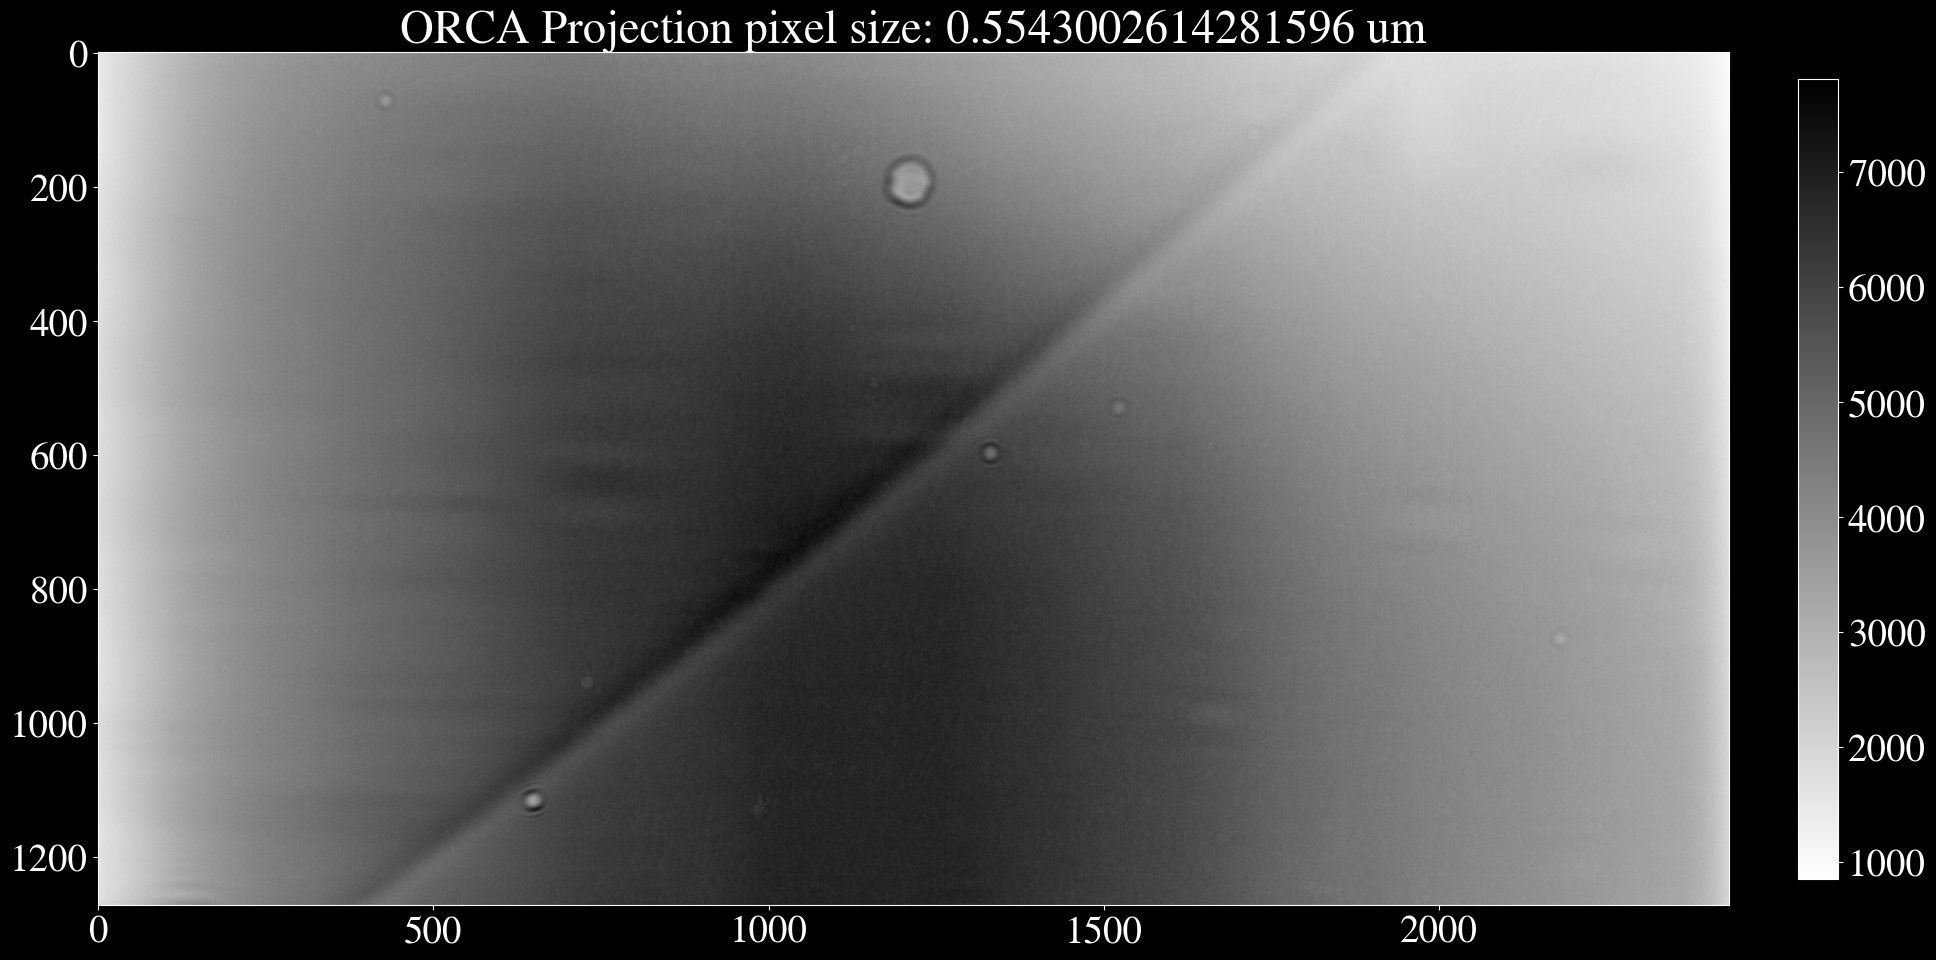

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
im = ax.imshow(projection, cmap='gray_r')
ax.set_title(f'ORCA Projection pixel size: {np.round(pixel_size_x, 3)} um')
fig.colorbar(im, ax=ax, fraction=0.023, pad=0.04)
plt.tight_layout()
plt.show()

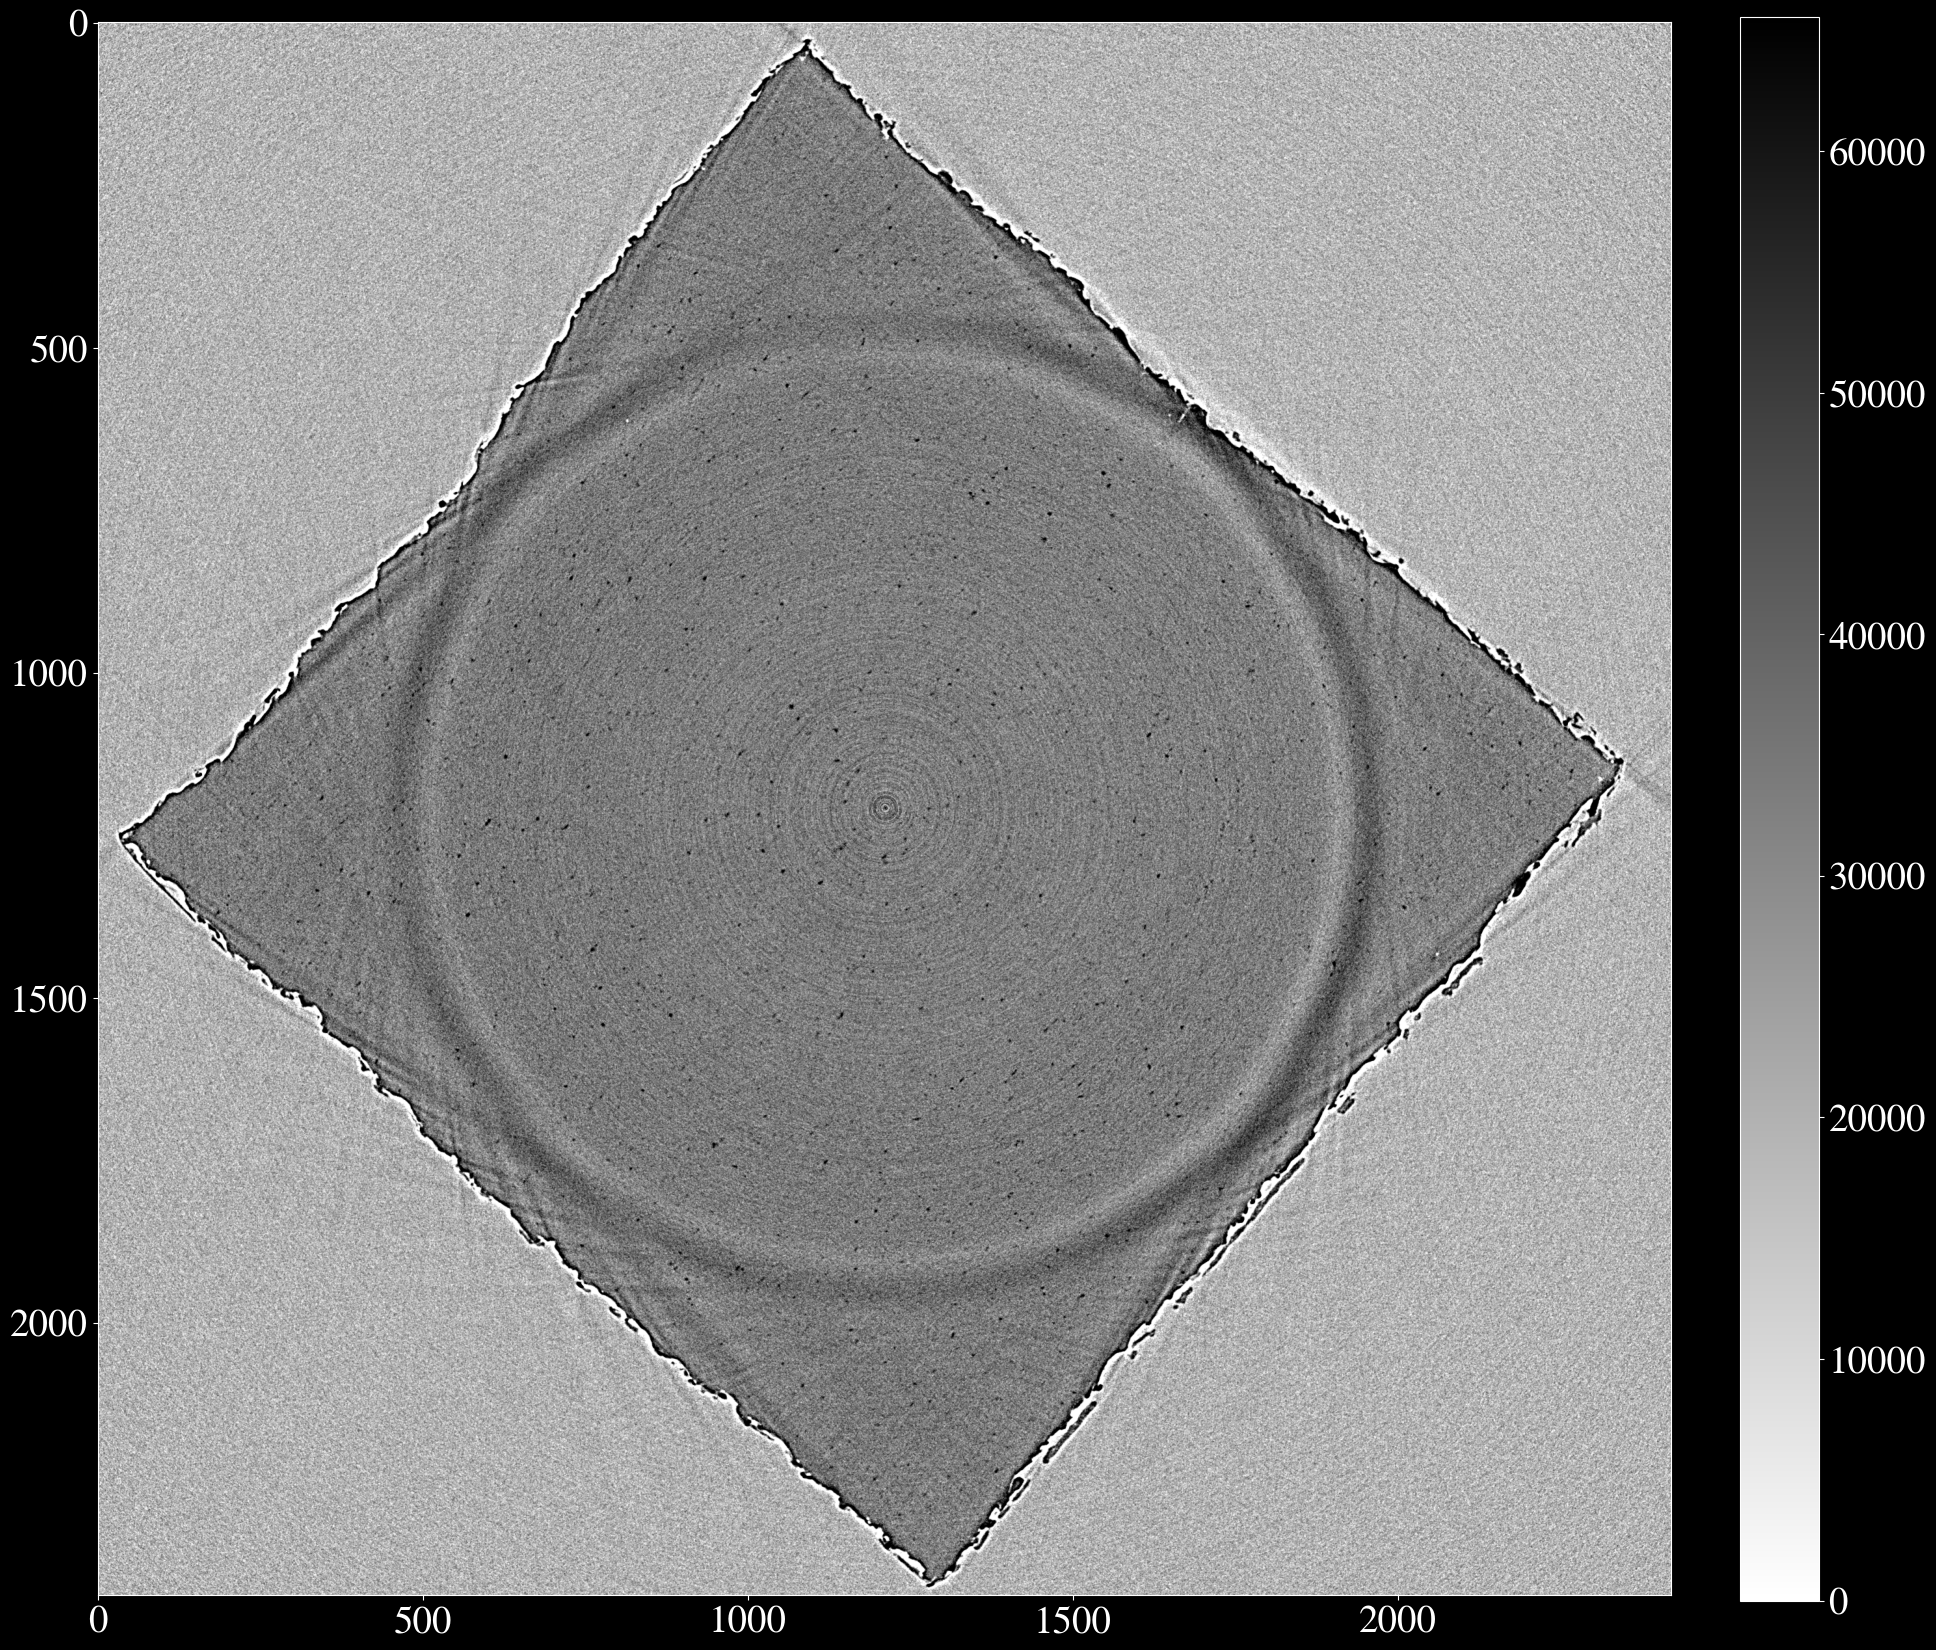

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
im = ax.imshow(vol[40, 700:-700, 700:-700], cmap='gray_r')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [63]:
ss = vol[40, 700:-700, 700:-700]

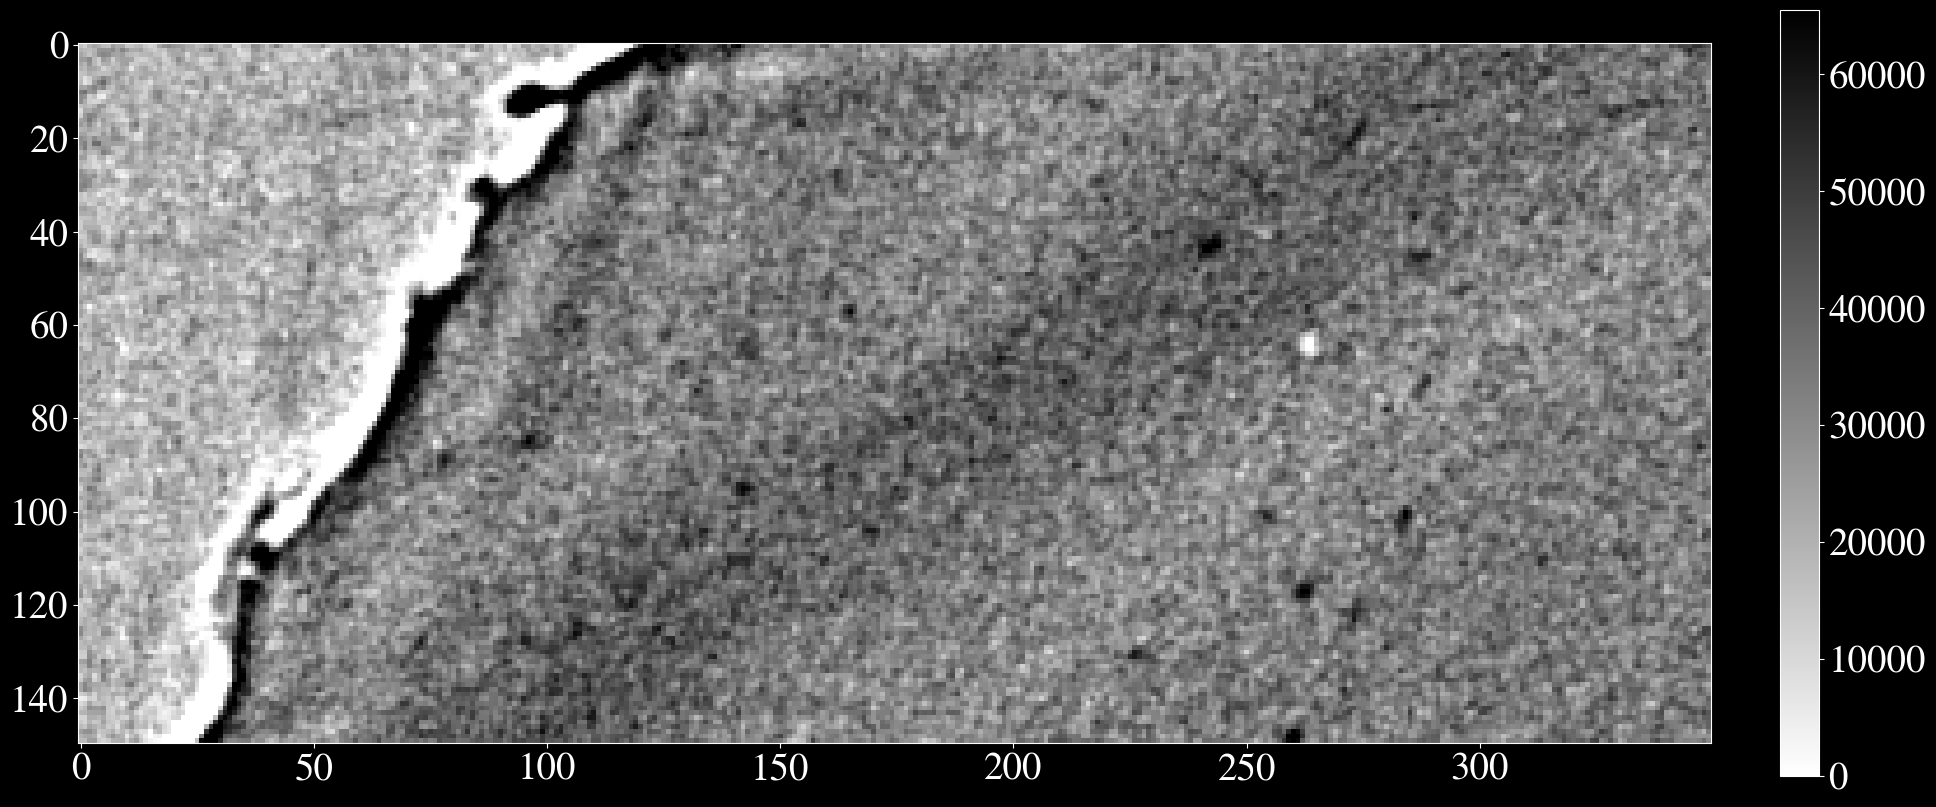

: 

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
im = ax.imshow(ss[550:700, 550:900], cmap='gray_r')
fig.colorbar(im, ax=ax, fraction=0.022, pad=0.04)
plt.tight_layout()
plt.show()